In [1]:
import os
os.chdir('..')
from gpu_management import set_gpus

os.environ['XLA_PYTHON_CLIENT_ALLOCATOR'] = 'platform'
# os.environ['CUDA_VISIBLE_DEVICES'] = '2,3'
set_gpus(1, forcing=True)

In [2]:
import pickle
import jax
import equinox as eqx

from data import make_dataset_from_args
from nlp import get_encoder
from models import get_model
from experiment import prepare_trainer

sameset = False
if sameset:
    path = "experiments/results/SameSet2"
    i_model = 13
else:
    path = "experiments/results/NewSet2"
    i_model = 25
with open(f'{path}/results.pkl', 'rb') as f:
    exp_args, results = pickle.load(f)
    results = results[i_model]
    args = results['config']
    print(args)
data_train, data_val, data_test = make_dataset_from_args(args.dataset)

encoder = get_encoder(args.encoder)

data_train.process_data(encoder, args.graph_density, args.graph_type)
data_val.process_data(encoder, args.graph_density, args.graph_type)
data_test.process_data(encoder, args.graph_density, args.graph_type)

model_params = args.model_params
key, subkey = jax.random.split(jax.random.PRNGKey(args.seed))
model, state = eqx.nn.make_with_state(get_model(args.model))( #type: ignore
    key=subkey, cards=data_train.cards, **model_params
)
params, static = eqx.partition(model, eqx.is_array)
trainer, opt_state, lr_transform, lr_transform_state = prepare_trainer(
    args, model, data_train.n_steps(args.batch_size)
)
static, key = trainer.shard_model(static, key)
params, state, opt_state = eqx.tree_deserialise_leaves(
    path+f'/model-{i_model+1:02}-{args.model}.eqx',
    (params, state, opt_state)
)
key, subkey = jax.random.split(key)
print(data_test.drafts.set_id.shape)
n_devices = len(jax.devices())
batch_size = max(1, (args.batch_size * n_devices) // 4)

Namespace(model='DraftTransformer2', model_params={'d_model': 64, 'dropout_p': 0.3, 'n_set_layers': 10, 'n_layers': 5, 'num_heads': 2, 'pred_n_layers': 2}, encoder='gemma', tokenizer='bert', use_meta=False, graph_density=0.05, graph_type='knn', epochs=25, batch_size=256, optimizer='adamw', lr=0.0001, scheduler='warmup_cosine', scheduler_params={'init_mult': '1e-1', 'warmup_steps': 5, 'end_mult': '1e-1'}, loss=['NLL', 'KL'], fine_tune=5, fine_tune_epochs=25, test_frequency=1, seed=42, dataset={'train_set': ['MOM', 'WOE', 'LCI', 'MKM', 'OTJ', 'BLB', 'DSK', 'DFT', 'TDM', 'FIN', 'EOE'], 'val_set': 'train', 'test_set': ['FDN'], 'temporal_split': False, 'time_window': 14, 'data_head': -1}, param_count=599745)
(22566,)


In [4]:
from data import DL17Lands

dataloaders = {
    exp: DL17Lands(exp)
    for exp in args.dataset['train_set' if sameset else 'test_set'] 
}

Loading FDN
-----------
Loading card data: 6.524710s
Making extension dataframe: 0.531647s
##################################################


In [5]:
dataloaders['FDN'].cards

id,expansion,name,rarity,color_identity,mana_value,types,is_booster,oracle,full_name,opening_hand,drawn,tutored,deck,sideboard,GIH,weight
i32,str,str,str,str,i8,str,bool,str,str,f32,f32,f32,f32,f32,f32,i32
93714,"""FDN""","""Sire of Seven Deaths""","""mythic""",null,7,"""Creature - Eldrazi""",true,"""[NAME] Sire of Seven Deaths | …","""Sire of Seven Deaths""",0.583793,0.642705,0.837037,0.565378,0.510638,0.619407,23020
93715,"""FDN""","""Arahbo, the First Fang""","""rare""","""W""",3,"""Legendary Creature - Cat Avata…",true,"""[NAME] Arahbo, the First Fang …","""Arahbo, the First Fang""",0.623466,0.598852,0.690537,0.573266,0.529436,0.609388,43390
93716,"""FDN""","""Armasaur Guide""","""common""","""W""",5,"""Creature - Dinosaur""",true,"""[NAME] Armasaur Guide | [MC] {…","""Armasaur Guide""",0.491876,0.513631,0.789474,0.519869,0.546262,0.504724,33041
93717,"""FDN""","""Cat Collector""","""uncommon""","""W""",3,"""Creature - Human Citizen""",true,"""[NAME] Cat Collector | [MC] {2…","""Cat Collector""",0.576994,0.595467,0.669903,0.567536,0.53617,0.587701,104233
93718,"""FDN""","""Celestial Armor""","""rare""","""W""",3,"""Artifact - Equipment""",true,"""[NAME] Celestial Armor | [MC] …","""Celestial Armor""",0.607376,0.628027,0.7,0.576384,0.527249,0.619639,47654
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
95195,"""FDN""","""Swamp""","""basic""","""B""",0,"""Basic Land - Swamp""",true,"""[NAME] Swamp | [COLOR] C | [RA…","""Swamp""",0.543869,0.545433,0.584108,0.54503,0.0,0.544788,2946947
95197,"""FDN""","""Mountain""","""basic""","""R""",0,"""Basic Land - Mountain""",true,"""[NAME] Mountain | [COLOR] C | …","""Mountain""",0.544125,0.525273,0.558555,0.547475,0.0,0.533514,2076789
95199,"""FDN""","""Forest""","""basic""","""G""",0,"""Basic Land - Forest""",true,"""[NAME] Forest | [COLOR] C | [R…","""Forest""",0.538228,0.527617,0.56822,0.538673,0.0,0.532346,1914614


In [6]:
data = data_train if sameset else data_test
print(data.sets.set_size)

[286]


In [7]:
i_set = 1 if sameset else 0
cards = data.cards[data.sets.card_ids[i_set,:data.sets.set_size[i_set]]]
cards

Cards(
  card_id=i32[286], textual_features=f32[286,768], numeric_features=f32[286,6]
)

In [8]:
import numpy as np

i_draft = np.argmax(data.drafts.set_id == i_set)
i_draft = np.argmax((data.drafts.rank == 6) & (data.drafts.set_id == i_set))
i_draft, data.drafts[i_draft].set_id

(Array(22, dtype=int32), Array(0, dtype=int16))

In [9]:
model = eqx.combine(params, static)
print(data.drafts[i_draft].rank)
context_encodings = model.get_context_encodings(key, data.cards, data.sets, data.drafts[i_draft], state, True)
context_encodings

6


Array([[-1.151594  , -0.48604903,  0.19171038, ...,  0.25386143,
        -0.7988099 , -0.0232283 ],
       [ 0.33574244, -0.887503  ,  0.00868571, ..., -0.24955839,
        -1.1687653 , -0.2910241 ],
       [-3.3683007 ,  2.6635337 ,  0.47389984, ..., -0.5134748 ,
        -1.12452   ,  1.0890467 ],
       ...,
       [-0.45272827, -1.1115206 ,  0.06109273, ..., -0.48797953,
        -2.3685002 ,  6.569495  ],
       [-0.50460464,  1.5459527 ,  0.7319125 , ...,  0.6649107 ,
        -2.7424605 ,  1.7434065 ],
       [-1.0231102 , -1.1561968 ,  0.30895224, ..., -0.18863234,
        -1.770835  , -1.8079472 ]], dtype=float32)

In [11]:
from sklearn.manifold import TSNE

raw_embeddings = np.array(data.cards[data.sets.card_ids[i_set,:data.sets.set_size[i_set]]].textual_features)
set_embeddings = np.array(context_encodings[:data.sets.set_size[i_set]])

sims_raw_textual = TSNE(n_components=2, learning_rate='auto', init='random', perplexity=5, random_state=4242).fit_transform(
    raw_embeddings
)
sims_context_textual = TSNE(n_components=2, learning_rate='auto', init='random', perplexity=5, random_state=4242).fit_transform(
    set_embeddings
)

In [13]:
import polars as pl

dataloaders['FDN'].cards.filter(pl.col('id') == cards[0].card_id)

id,expansion,name,rarity,color_identity,mana_value,types,is_booster,oracle,full_name,opening_hand,drawn,tutored,deck,sideboard,GIH,weight
i32,str,str,str,str,i8,str,bool,str,str,f32,f32,f32,f32,f32,f32,i32
93714,"""FDN""","""Sire of Seven Deaths""","""mythic""",null,7,"""Creature - Eldrazi""",true,"""[NAME] Sire of Seven Deaths | …","""Sire of Seven Deaths""",0.583793,0.642705,0.837037,0.565378,0.510638,0.619407,23020


In [14]:
colors = np.array([
    dataloaders['FDN'].cards.filter(pl.col('id') == cards.card_id[i])['color_identity'].item()
    for i in range(cards.card_id.shape[0])
])
set(colors)

{'B',
 'BG',
 'BGRUW',
 'BGU',
 'BR',
 'BU',
 'BW',
 'G',
 'GR',
 'GU',
 'GW',
 None,
 'R',
 'RU',
 'RW',
 'U',
 'UW',
 'W'}

In [15]:
import seaborn as sns

palette = {
    'W': '#FFEE00',
    'U': '#0000FF',
    'B': '#000000',
    'R': '#FF0000',
    'G': '#00DD00',
    'L': '#7C4700',
    'C': '#888888',
    'M': '#BF40BF',
}
legend_translate = {
    'W': 'White',
    'U': 'Blue',
    'B': 'Black',
    'R': 'Red',
    'G': 'Green',
    'L': 'Land',
    'C': 'Colorless',
    'M': 'Multicolor'
}
for i in range(len(colors)):
    if 'Land' in dataloaders['FDN'].cards.filter(pl.col('id') == cards.card_id[i])['types'].item():
        colors[i] = 'L'
    elif dataloaders['FDN'].cards.filter(pl.col('id') == cards.card_id[i])['color_identity'].item() is None:
        colors[i] = 'C'
    elif len(dataloaders['FDN'].cards.filter(pl.col('id') == cards.card_id[i])['color_identity'].item()) > 1:
        colors[i] = 'M'

In [16]:
palette_rarity = {"common": "gray", "uncommon": "steelblue", "rare": "gold", "mythic": "orange", 'basic': '#7C4700'}
rarities = np.array([
    dataloaders['FDN'].cards.filter(pl.col('id') == cards.card_id[i])['rarity'].item()
    for i in range(cards.card_id.shape[0])
])
set(rarities)

{np.str_('basic'),
 np.str_('common'),
 np.str_('mythic'),
 np.str_('rare'),
 np.str_('uncommon')}

In [17]:
gih_wr = data.cards[data.sets[i_set].card_ids].numeric_features[:data.sets.set_size[i_set],-1]
gih_wr.shape

(286,)

In [18]:
palettes = {
    'Card color identity': (palette, colors),
    # 'rarities': (palette_rarity, rarities),
    'Game-in-hand win rate': ("RdBu_r", gih_wr)
}

<Axes: ylabel='Density'>

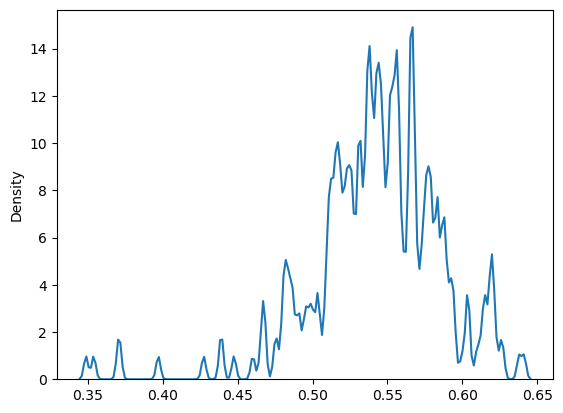

In [19]:
sns.kdeplot(gih_wr, bw_adjust=0.1)

In [20]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.linear_model import RidgeCV
import dcor

def compute_embedding_stats(embeddings, target, n_pcs=50):
    scaler = StandardScaler()
    X = scaler.fit_transform(embeddings)

    n_pcs = min(n_pcs, X.shape[1], X.shape[0])  # can't exceed either dimension
    pipe = Pipeline([
        ('pca', PCA(n_components=n_pcs)),
        ('ridge', RidgeCV(alphas=np.logspace(-3, 3, 20)))
    ])
    r2_scores = cross_val_score(pipe, X, target, cv=5, scoring='r2')
    r2 = r2_scores.mean()

    # Distance correlation on raw (basis-free, no preprocessing needed)
    dc = dcor.distance_correlation(embeddings, np.asarray(target))

    return (
        f"Distance correlation: {dc:.3f}\n"
        f"Linear R² (PCA+Ridge, 5-fold CV): {r2:.3f}"
    )

compute_embedding_stats(set_embeddings, gih_wr), compute_embedding_stats(raw_embeddings, gih_wr)

('Distance correlation: 0.634\nLinear R² (PCA+Ridge, 5-fold CV): 0.316',
 'Distance correlation: 0.348\nLinear R² (PCA+Ridge, 5-fold CV): -0.019')

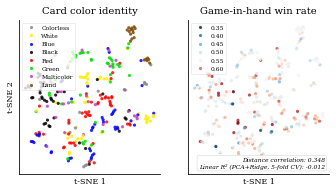

In [21]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import TwoSlopeNorm

def plot_tsne(coords, palettes, mask=None, annotations=None, legend_translate=None):
    mpl.rcParams.update({
        "font.family": "serif",
        "font.size": 10,
        "axes.labelsize": 8,
        "axes.titlesize": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "legend.frameon": True,
        "legend.fontsize": 6,
        "figure.dpi": 72,
    })
    if mask is None:
        mask = np.ones(len(coords), dtype=bool)
    mask = np.asarray(mask, dtype=bool)
    
    fig, (axs) = plt.subplots(1, len(palettes), figsize=(400/72, 400/72/len(palettes)))
    
    for ax, (label, (palette, values)) in zip(axs, palettes.items()):
        v = values[mask]
        
        # For continuous palettes, normalize so midpoint is visually centered
        hue_norm = None
        if isinstance(palette, str) and v.dtype.kind == 'f':
            hue_norm = TwoSlopeNorm(vmin=v.min(), vcenter=np.median(v), vmax=v.max())

        sns.scatterplot(ax=ax, x=coords[mask,0], y=coords[mask,1], hue=v, hue_norm=hue_norm, palette=palette, s=10, linewidth=0, alpha=0.85)

        if annotations and label in annotations:
            ax.text(
                0.97, 0.03, annotations[label],
                transform=ax.transAxes,
                ha='right', va='bottom',
                fontsize=6, style='italic',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='lightgray', linewidth=0.5)
            )
        
        ax.set_title(label)
        ax.set_xlabel("t-SNE 1")
        ax.set_ylabel("t-SNE 2") if ax is axs[0] else ax.set_ylabel("")
        ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
        # ax.legend(loc="best", markerscale=1.2)
        legend = ax.get_legend()
        if legend:
            if legend_translate and label in legend_translate:
                translate = legend_translate[label]
                for text in legend.get_texts():
                    text.set_text(translate.get(text.get_text(), text.get_text()))
            legend.get_frame().set_linewidth(0.5)
            legend.get_frame().set_edgecolor('lightgray')
    return fig

fig = plot_tsne(sims_raw_textual, palettes, annotations={'Game-in-hand win rate': compute_embedding_stats(raw_embeddings, gih_wr)}, legend_translate={'Card color identity': legend_translate})
fig.savefig(f'figures/tsne_rawemb_{'same' if sameset else 'new'}.pdf', bbox_inches="tight")

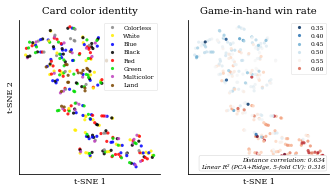

In [22]:
fig = plot_tsne(sims_context_textual, palettes, annotations={'Game-in-hand win rate': compute_embedding_stats(set_embeddings, gih_wr)}, legend_translate={'Card color identity': legend_translate})
fig.savefig(f'figures/tsne_setemb_{'same' if sameset else 'new'}.pdf', bbox_inches="tight")

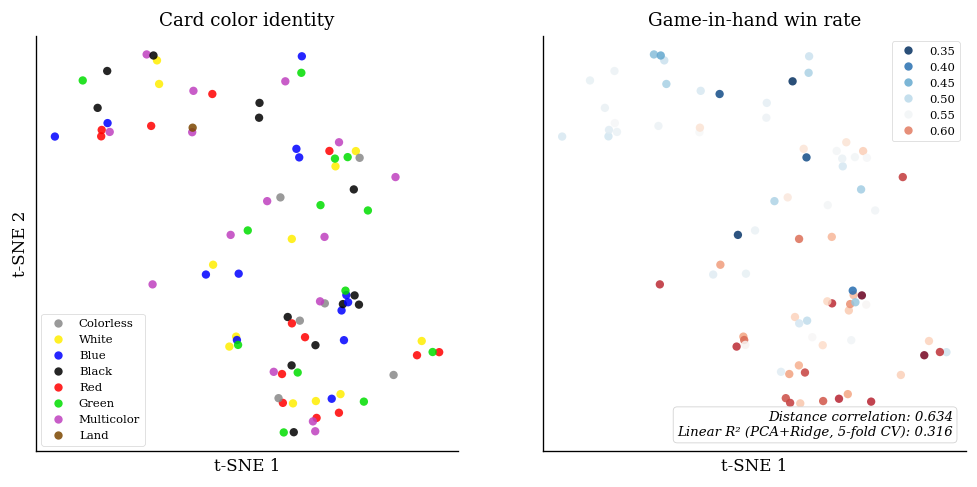

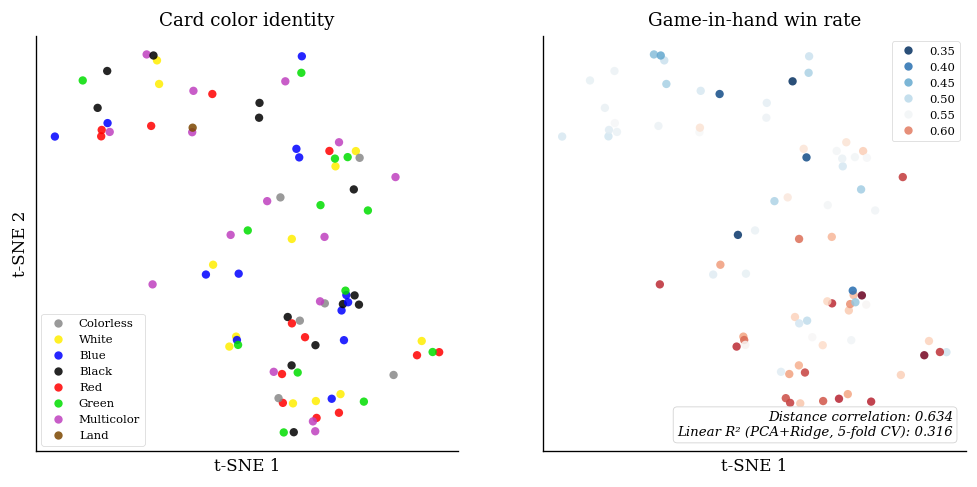

In [23]:
rare_mask = np.array([r in ('rare', 'mythic') for r in rarities])
plot_tsne(sims_context_textual, palettes, mask=rare_mask, annotations={'Game-in-hand win rate': compute_embedding_stats(set_embeddings, gih_wr)}, legend_translate={'Card color identity': legend_translate})

In [24]:
set_embeddings.shape, raw_embeddings.shape

((286, 64), (286, 768))

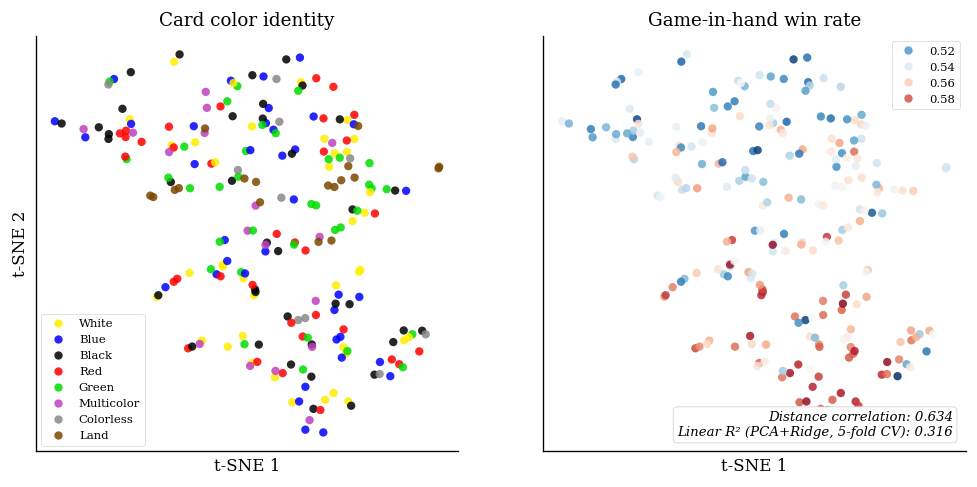

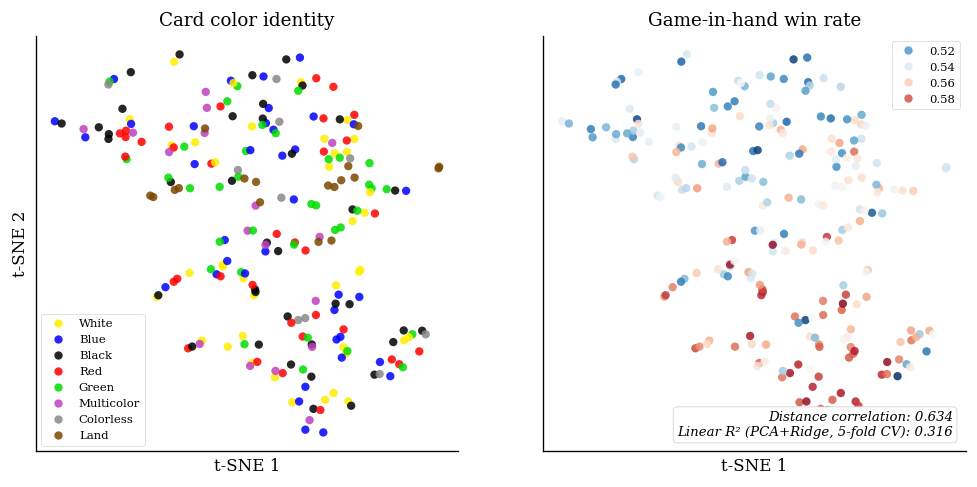

In [25]:
mask = (gih_wr > 0.5) & (gih_wr < 0.6)
plot_tsne(sims_context_textual, palettes, mask=mask, annotations={'Game-in-hand win rate': compute_embedding_stats(set_embeddings, gih_wr)}, legend_translate={'Card color identity': legend_translate})

In [26]:
%time
from sklearn.metrics.pairwise import cosine_similarity

raw_sims = cosine_similarity(raw_embeddings, raw_embeddings)
set_sims = cosine_similarity(set_embeddings, set_embeddings)

CPU times: user 16 μs, sys: 2 μs, total: 18 μs
Wall time: 33.1 μs


In [27]:
def get_inter_stats(sims, cats):
    res = {}
    for i in range(sims.shape[0]):
        if cats[i] not in res:
            res[cats[i]] = {}
        for j in range(sims.shape[0]):
            if i == j: continue
            if cats[j] not in res[cats[i]]:
                res[cats[i]][cats[j]] = [0, 0]
            res[cats[i]][cats[j]][0] += 1
            res[cats[i]][cats[j]][1] += sims[i][j]
    return res

raw_inter_color = get_inter_stats(raw_sims, colors)
set_inter_color = get_inter_stats(set_sims, colors)

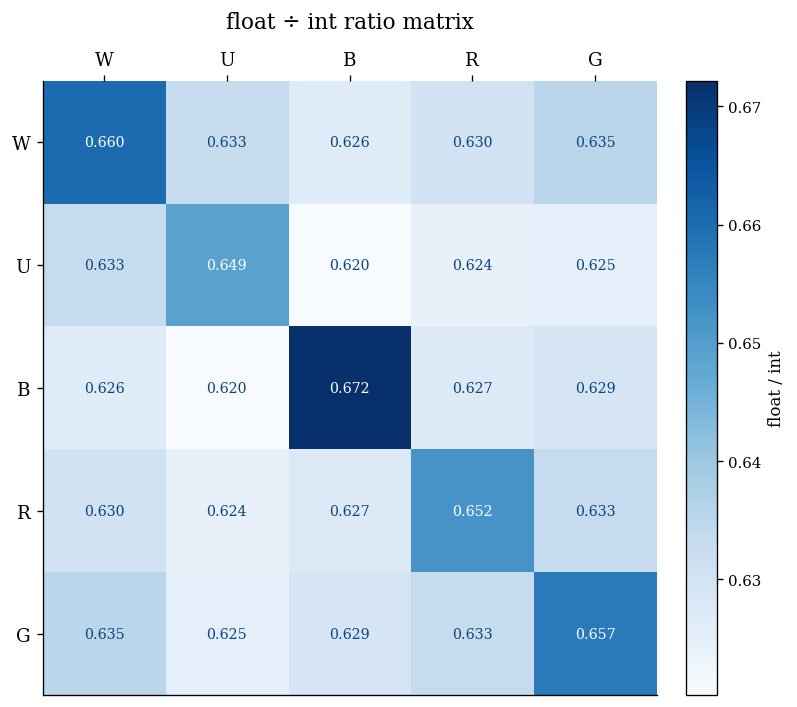

In [28]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def plot_inter_sims(inter):
    keys = list(inter.keys())
    keys = ['W', 'U', 'B', 'R', 'G']
    n = len(keys)
    matrix = np.array([[inter[r][c][1] / inter[r][c][0] for c in keys] for r in keys])
    
    fig, ax = plt.subplots(figsize=(7, 6))
    
    cmap = plt.get_cmap('Blues')
    im = ax.imshow(matrix, cmap=cmap, aspect='equal')
    
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(keys, fontsize=11)
    ax.set_yticklabels(keys, fontsize=11)
    ax.xaxis.tick_top()
    
    vmin, vmax = matrix.min(), matrix.max()
    for i in range(n):
        for j in range(n):
            v = matrix[i, j]
            t = (v - vmin) / (vmax - vmin)
            color = 'white' if t > 0.55 else '#0C447C'
            ax.text(j, i, f'{v:.3f}', ha='center', va='center', fontsize=8.5,
                    fontweight='500', color=color)
    
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=9)
    cbar.set_label('float / int', fontsize=10)
    
    ax.set_title('float ÷ int ratio matrix', fontsize=13, fontweight='500', pad=14)
    
    plt.tight_layout()
    # plt.savefig('/mnt/user-data/outputs/matrix_heatmap.png', dpi=150, bbox_inches='tight')

plot_inter_sims(raw_inter_color)

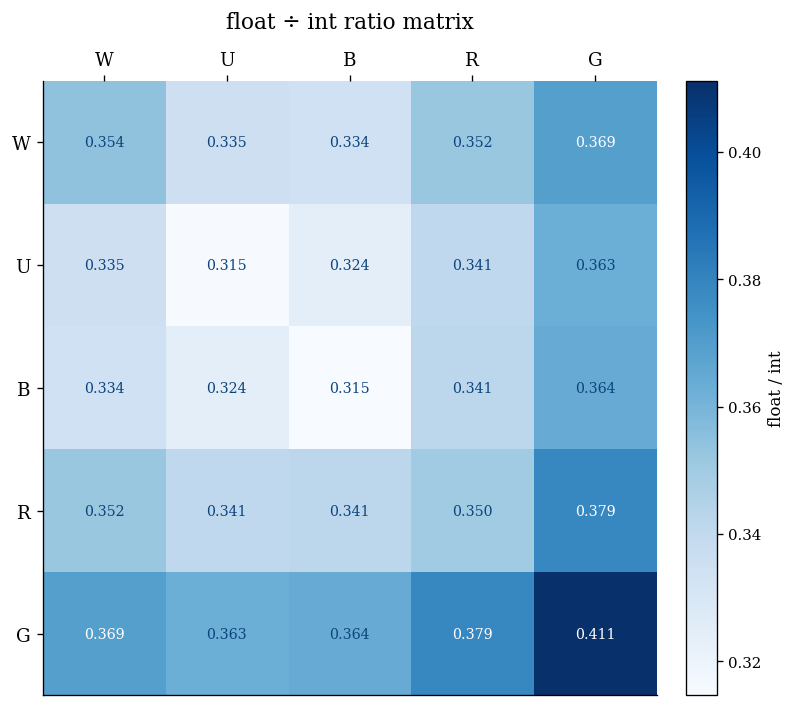

In [29]:
plot_inter_sims(set_inter_color)

In [32]:
%time
def lf_len(lf):
    return lf.select(pl.len()).collect().item()

def cooccurences(lf, all_ids, groupby='draft_id', col='pick_id'):
    grouped_picks = (
        lf.select(pl.col(groupby), pl.col(col), (pl.col('pack_number') * 15 + pl.col('pick_number')).alias('_elem_idx'))
          .rename({groupby: '_row', col: 'i'})
    )
    # with pl.Config(tbl_rows=45):
    #     print(lf_len(grouped_picks), grouped_picks.filter(pl.col('_row') == '000078e71124496383cecc3ae823ddc1').collect())
    pairs = (
        grouped_picks.join(grouped_picks, on='_row', suffix='_right')
                     .rename({'i_right': 'j'})
                     .filter(pl.col("_elem_idx") != pl.col("_elem_idx_right"))
                     .group_by(["i", "j"])
                     .agg(pl.len().alias("count"))
    )
    return (
        pairs.collect()
             .pivot(on='j', index='i', values='count', aggregate_function='sum')
    )

fdn_cm = cooccurences(dataloaders['FDN'].drafts, dataloaders['FDN'].cards['id'].to_list())
fdn_cm

CPU times: user 17 μs, sys: 1 μs, total: 18 μs
Wall time: 37.7 μs


i,93817,93913,93910,93897,93777,93742,93961,93980,93740,93725,93987,93764,93944,93779,93789,93816,93768,93950,93829,93894,93837,93920,93760,93819,95197,93889,93822,93881,93901,93975,93826,93758,93899,93843,93726,93978,…,93945,93741,93801,93990,93809,93915,93791,93769,93973,93761,93754,93934,93948,93813,95193,93717,93721,93845,93802,93753,93895,93748,93965,93917,93719,93788,93927,93858,93864,93729,93807,93744,93956,93930,93783,93722,93782
i64,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,…,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
93807,1572,8288,2585,616,4632,1178,715,1149,214,3025,31,215,1057,549,1414,2669,1594,2176,360,3201,3674,1247,1155,536,4194,315,578,1879,4260,4873,850,527,1537,3532,2931,3616,…,697,2077,2120,54,4089,2256,4888,1341,1305,2875,401,474,3427,3747,4010,1201,1283,871,9951,443,1390,488,2635,1652,1357,3667,2783,1311,748,3299,5022,3095,177,1068,3679,2597,1364
93730,205,540,170,119,696,280,141,253,85,1406,6,55,179,92,285,410,285,206,150,706,199,78,311,72,739,54,81,569,208,884,76,102,286,751,1298,266,…,80,1225,163,9,194,301,228,233,531,766,92,111,479,479,747,577,426,147,606,106,211,125,705,81,457,770,483,501,173,1667,224,761,39,161,772,1473,282
93781,1552,5431,1641,2514,16810,2359,1116,2545,777,9069,94,512,1354,2224,6445,3482,6747,1552,595,13428,5225,928,2478,649,7701,1173,736,4513,2271,9151,735,1108,6492,6933,7697,2572,…,783,8327,1861,54,2456,2803,2642,5285,3178,6946,893,767,3931,3702,7589,4728,2283,1550,7197,906,5472,963,6721,978,2810,14709,4105,2904,1588,9687,2460,6621,609,1371,15158,10104,5633
93977,1250,2919,899,571,4007,1192,512,1184,283,3777,23,225,933,526,1313,2474,1577,955,475,3251,1430,448,1296,499,3015,300,499,2274,1357,3460,594,533,1441,2916,3448,1613,…,651,2910,967,29,1406,1241,1532,1137,1642,3346,422,427,3002,3140,2983,1535,1070,595,3662,482,1236,498,2470,524,1317,3355,2417,1332,819,3994,1502,3209,200,986,3578,3586,1287
93763,1008,3147,1236,642,3916,3940,762,1261,289,3603,31,722,698,495,902,1867,1502,2994,292,4008,881,551,4895,397,4264,316,403,7000,1428,5210,457,1623,1518,3150,3621,1392,…,484,3244,934,33,1050,1332,1174,1531,1559,11152,1335,416,2479,2072,4250,1544,797,855,3019,1508,1188,1681,3733,451,1180,3192,2311,1124,2218,4330,1095,10897,390,689,3322,4098,1496
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
93825,1504,1156,337,251,1538,522,256,632,100,1451,13,118,1007,240,421,2668,576,349,409,1341,466,212,569,464,1651,120,437,1055,658,2310,576,231,560,1429,1267,1685,…,570,962,402,52,597,480,758,510,1421,1405,198,309,3610,3354,1673,594,388,273,1724,202,565,216,1380,247,480,1418,2197,479,360,1482,769,1489,239,981,1451,1198,521
93790,408,1278,415,496,3527,623,299,582,107,1210,21,126,296,449,1151,825,1343,343,121,2600,1186,198,583,161,1645,260,176,1027,581,1949,150,302,1254,1236,1078,567,…,190,1096,386,9,612,614,693,1214,537,1651,209,193,856,842,1582,541,370,305,1674,221,1235,229,1279,270,452,2933,910,419,377,1339,670,1483,187,311,3940,1293,1100
93912,964,6931,2008,525,3617,918,526,1002,232,3253,24,218,731,490,1242,1725,1305,1685,330,2714,2699,743,985,363,3143,222,405,1550,2945,3622,484,405,1254,2967,3026,2119,…,492,2251,1773,41,2823,1740,3246,1096,1083,2493,317,374,2124,2305,3159,1293,1353,637,6740,360,1206,443,2135,1470,1420,2913,1913,1407,628,3457,3179,2520,143,654,3058,2841,1170


In [33]:
zero_coords = fdn_cm.unpivot(index="i", variable_name="j", value_name="count") \
      .filter(pl.col("count") == 0) \
      .select(["i", "j"]) \
      .with_columns(pl.col("j").cast(pl.Int64))
zero_coords

i,j
i64,i64
93988,93987
93986,93987
93989,93987
93987,93987
93992,93987
…,…
93987,93989
95282,93989
93985,93990


In [34]:
with pl.Config(tbl_rows=45):
    print(zero_coords \
        .join(dataloaders['FDN'].cards.rename({"id": "i", "name": "i_name"}), on="i") \
        .join(dataloaders['FDN'].cards.rename({"id": "j", "name": "j_name"}), on="j") \
        .select(pl.col("i_name").alias("i"), pl.col("j_name").alias("j"))
        .sort("i")
    )

shape: (45, 2)
┌───────────────────────┬───────────────────────┐
│ i                     ┆ j                     │
│ ---                   ┆ ---                   │
│ str                   ┆ str                   │
╞═══════════════════════╪═══════════════════════╡
│ Akroma's Memorial     ┆ Grim Tutor            │
│ Akroma's Memorial     ┆ Temporal Manipulation │
│ Akroma's Memorial     ┆ Fiend Artisan         │
│ Bloom Tender          ┆ Condemn               │
│ Bloom Tender          ┆ Embercleave           │
│ Bloom Tender          ┆ Bloom Tender          │
│ Condemn               ┆ Condemn               │
│ Condemn               ┆ Sphinx's Tutelage     │
│ Condemn               ┆ Goblin Bushwhacker    │
│ Condemn               ┆ Paradise Druid        │
│ Condemn               ┆ Bloom Tender          │
│ Embercleave           ┆ Sphinx's Tutelage     │
│ Embercleave           ┆ Grim Tutor            │
│ Embercleave           ┆ Embercleave           │
│ Embercleave           ┆ Paradise 

In [35]:
gathererid_to_id = {
    cards.card_id[idx].item(): idx
    for idx in range(len(cards.card_id))
}

fdn_coocc = np.zeros((len(cards.card_id), len(cards.card_id)), dtype=np.int64)
melted = (
    fdn_cm.unpivot(index="i", variable_name="j", value_name="count")
          .with_columns(pl.col("j").cast(pl.Int64))
)

rows = melted["i"].replace(gathererid_to_id).to_numpy()
cols = melted["j"].replace(gathererid_to_id).to_numpy()
vals = melted["count"].to_numpy()

fdn_coocc[rows, cols] = vals
fdn_coocc

array([[  44,  139,  634, ...,  862,    8,    8],
       [ 139,  530, 2469, ..., 1809,   18,   12],
       [ 634, 2469, 8320, ..., 6913,   80,   79],
       ...,
       [ 862, 1809, 6913, ..., 4600,  125,   99],
       [   8,   18,   80, ...,  125,    2,    0],
       [   8,   12,   79, ...,   99,    0,    0]], shape=(286, 286))

In [36]:
raw_sims

array([[1.        , 0.5918523 , 0.63258195, ..., 0.5880856 , 0.6082573 ,
        0.6543615 ],
       [0.5918523 , 1.0000001 , 0.62477136, ..., 0.6183891 , 0.59260267,
        0.63382363],
       [0.63258195, 0.62477136, 1.0000001 , ..., 0.59849674, 0.6073123 ,
        0.58642316],
       ...,
       [0.5880856 , 0.6183891 , 0.59849674, ..., 1.        , 0.64085525,
        0.6197181 ],
       [0.6082573 , 0.59260267, 0.6073123 , ..., 0.64085525, 1.0000001 ,
        0.65484756],
       [0.6543615 , 0.63382363, 0.58642316, ..., 0.6197181 , 0.65484756,
        1.0000001 ]], shape=(286, 286), dtype=float32)

Spearman ρ = 0.102, p = 1.10e-188
co >=     0  n= 81510  ρ=0.102
co >=    10  n= 81142  ρ=0.104
co >=   100  n= 75760  ρ=0.126
co >=   500  n= 58724  ρ=0.118
co >=  1000  n= 43506  ρ=0.107


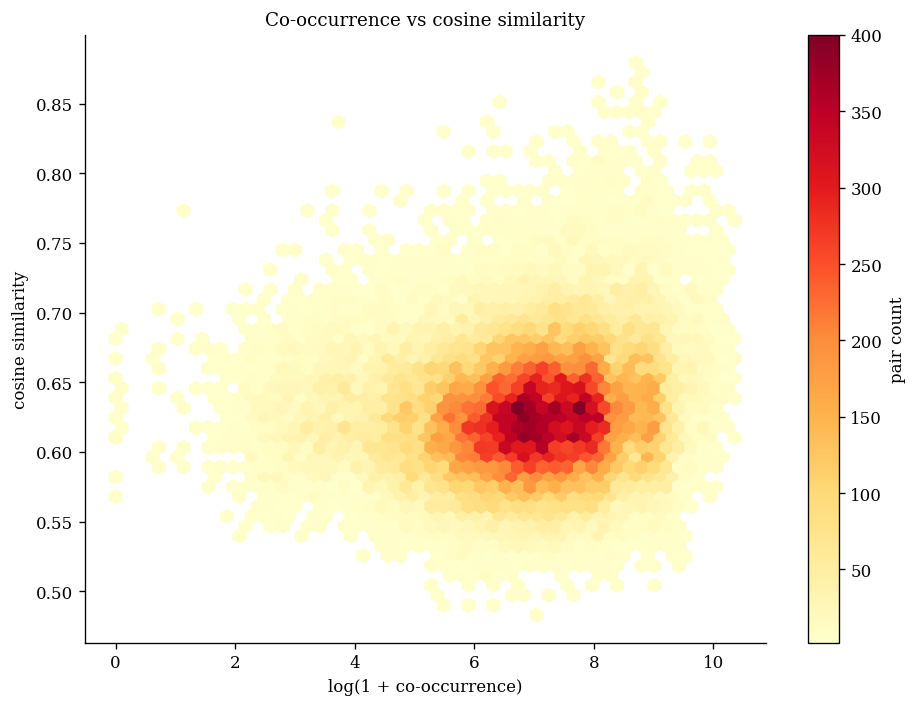

In [37]:
from scipy import stats

# Flatten both matrices, exclude diagonal
mask = ~np.eye(286, dtype=bool)
co = fdn_coocc[mask].flatten()
cos = raw_sims[mask].flatten()

# Optional: only plot pairs where at least one matrix is nonzero
nonzero = (co > 0) | (cos > 0)
co, cos = co[nonzero], cos[nonzero]

plt.figure(figsize=(8, 6))
plt.hexbin(np.log1p(co), cos, gridsize=50, cmap="YlOrRd", mincnt=1)
plt.xlabel("log(1 + co-occurrence)")
plt.colorbar(label="pair count")
plt.ylabel("cosine similarity")
plt.title("Co-occurrence vs cosine similarity")
plt.tight_layout()

# Spearman is better here since the relationship looks monotonic but not linear
rho, pval = stats.spearmanr(np.log1p(co), cos)
print(f"Spearman ρ = {rho:.3f}, p = {pval:.2e}")
thresholds = [0, 10, 100, 500, 1000]
for t in thresholds:
    mask = co >= t
    rho, _ = stats.spearmanr(np.log1p(co[mask]), cos[mask])
    print(f"co >= {t:5d}  n={mask.sum():6d}  ρ={rho:.3f}")

Spearman ρ = 0.071, p = 7.07e-91
co >=     0  n= 81502  ρ=0.071
co >=    10  n= 81142  ρ=0.071
co >=   100  n= 75760  ρ=0.079
co >=   500  n= 58724  ρ=0.060
co >=  1000  n= 43506  ρ=0.057


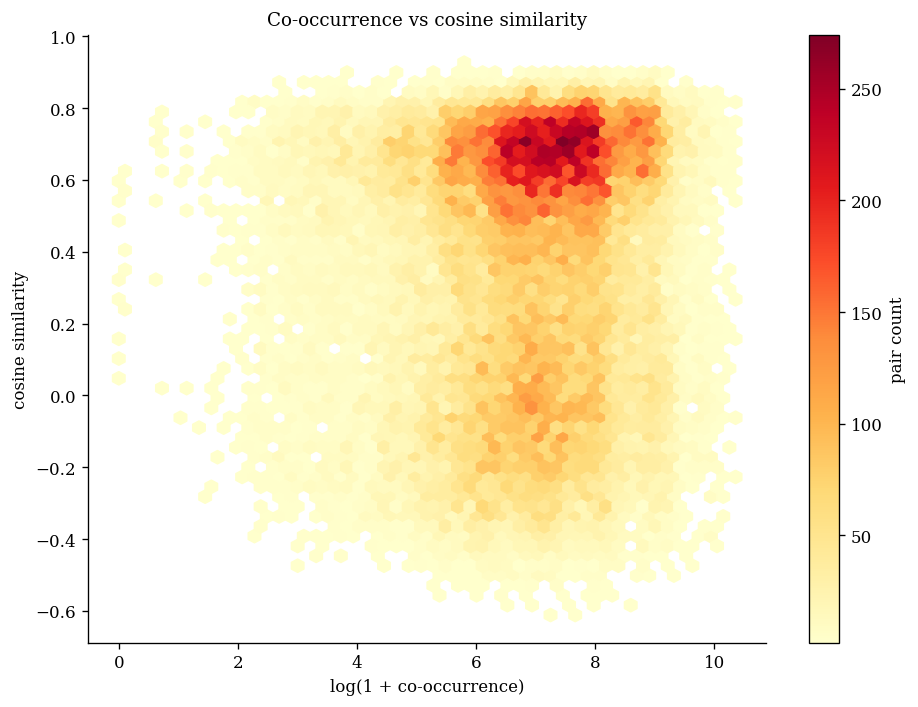

In [38]:
# Flatten both matrices, exclude diagonal
mask = ~np.eye(286, dtype=bool)
co = fdn_coocc[mask].flatten()
cos = set_sims[mask].flatten()

# Optional: only plot pairs where at least one matrix is nonzero
nonzero = (co > 0) | (cos > 0)
co, cos = co[nonzero], cos[nonzero]

plt.figure(figsize=(8, 6))
plt.hexbin(np.log1p(co), cos, gridsize=50, cmap="YlOrRd", mincnt=1)
plt.xlabel("log(1 + co-occurrence)")
plt.colorbar(label="pair count")
plt.ylabel("cosine similarity")
plt.title("Co-occurrence vs cosine similarity")
plt.tight_layout()

# Spearman is better here since the relationship looks monotonic but not linear
rho, pval = stats.spearmanr(np.log1p(co), cos)
print(f"Spearman ρ = {rho:.3f}, p = {pval:.2e}")
thresholds = [0, 10, 100, 500, 1000]
for t in thresholds:
    mask = co >= t
    rho, _ = stats.spearmanr(np.log1p(co[mask]), cos[mask])
    print(f"co >= {t:5d}  n={mask.sum():6d}  ρ={rho:.3f}")

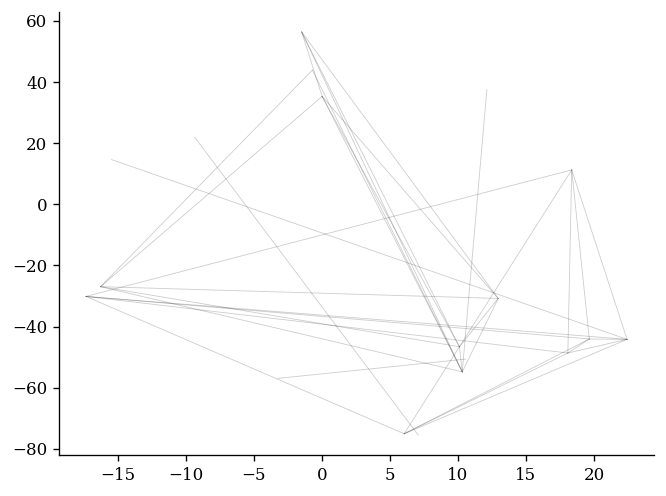

In [39]:
top_pairs = np.argwhere(fdn_coocc > np.percentile(fdn_coocc, 99.9))
for i, j in top_pairs:
    plt.plot([sims_context_textual[i,0], sims_context_textual[j,0]], [sims_context_textual[i,1], sims_context_textual[j,1]], 
             'k-', alpha=0.1, linewidth=0.5)